## Imports

In [2]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

#from neuro_fuzzy_toolbox import h_ANFIS, Gaussian_MF
import neuro_fuzzy_toolbox as nft

## Data

In [3]:
x_train = 2 * torch.rand(200, 3) - 1
x_train

tensor([[ 0.6900, -0.6010, -0.2253],
        [-0.4532,  0.8064,  0.1388],
        [ 0.4924, -0.1040, -0.3967],
        [ 0.5621, -0.3609,  0.3036],
        [-0.0027,  0.7875,  0.8050],
        [ 0.1391,  0.7721,  0.8045],
        [ 0.6108,  0.9718, -0.9004],
        [-0.8388,  0.8336,  0.1511],
        [ 0.3606, -0.8963, -0.0952],
        [-0.6032,  0.0321,  0.6995],
        [ 0.1890,  0.5206, -0.5839],
        [ 0.6602, -0.7094, -0.2216],
        [-0.9956,  0.6836, -0.8716],
        [-0.7578,  0.5809,  0.7687],
        [ 0.0538, -0.6900, -0.7218],
        [-0.7460, -0.2906, -0.9448],
        [ 0.0581, -0.3041, -0.7815],
        [-0.5855, -0.7308,  0.0112],
        [-0.6652,  0.0208,  0.0889],
        [-0.0612,  0.7270,  0.3159],
        [-0.0659, -0.8666,  0.1307],
        [ 0.7947, -0.2115,  0.1792],
        [-0.1299,  0.5409,  0.5207],
        [-0.4496,  0.6055,  0.9175],
        [-0.6180, -0.6845,  0.2540],
        [-0.5411, -0.9575, -0.1773],
        [ 0.9785,  0.8592,  0.8810],
 

In [4]:
y_train = torch.rand(200)
y_train

tensor([0.6372, 0.3199, 0.8955, 0.0744, 0.4599, 0.2493, 0.3631, 0.7834, 0.9713,
        0.7779, 0.7274, 0.4320, 0.3214, 0.8185, 0.4175, 0.8761, 0.9988, 0.2930,
        0.6685, 0.0090, 0.7140, 0.2543, 0.0068, 0.6286, 0.5579, 0.0364, 0.4425,
        0.0666, 0.3675, 0.8329, 0.5737, 0.4204, 0.4670, 0.2576, 0.2144, 0.7265,
        0.2794, 0.3792, 0.7214, 0.1963, 0.2951, 0.8354, 0.6497, 0.2476, 0.4253,
        0.8751, 0.9404, 0.1706, 0.6650, 0.2351, 0.0701, 0.3367, 0.4193, 0.9004,
        0.1865, 0.7722, 0.2987, 0.6584, 0.9589, 0.3995, 0.7395, 0.9067, 0.8588,
        0.7880, 0.7952, 0.1482, 0.8080, 0.0520, 0.5821, 0.7517, 0.3239, 0.0412,
        0.6142, 0.6740, 0.7487, 0.3982, 0.7050, 0.9914, 0.4407, 0.8784, 0.2508,
        0.6488, 0.8443, 0.8310, 0.4927, 0.6009, 0.0494, 0.5279, 0.1333, 0.8106,
        0.9587, 0.4210, 0.1575, 0.9755, 0.6924, 0.9144, 0.1156, 0.9400, 0.0194,
        0.1633, 0.8371, 0.2721, 0.3078, 0.0641, 0.6959, 0.4375, 0.3676, 0.1583,
        0.6284, 0.4233, 0.9667, 0.5148, 

## Model

In [5]:
model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='regression', # Tipo de salida: regresión
)

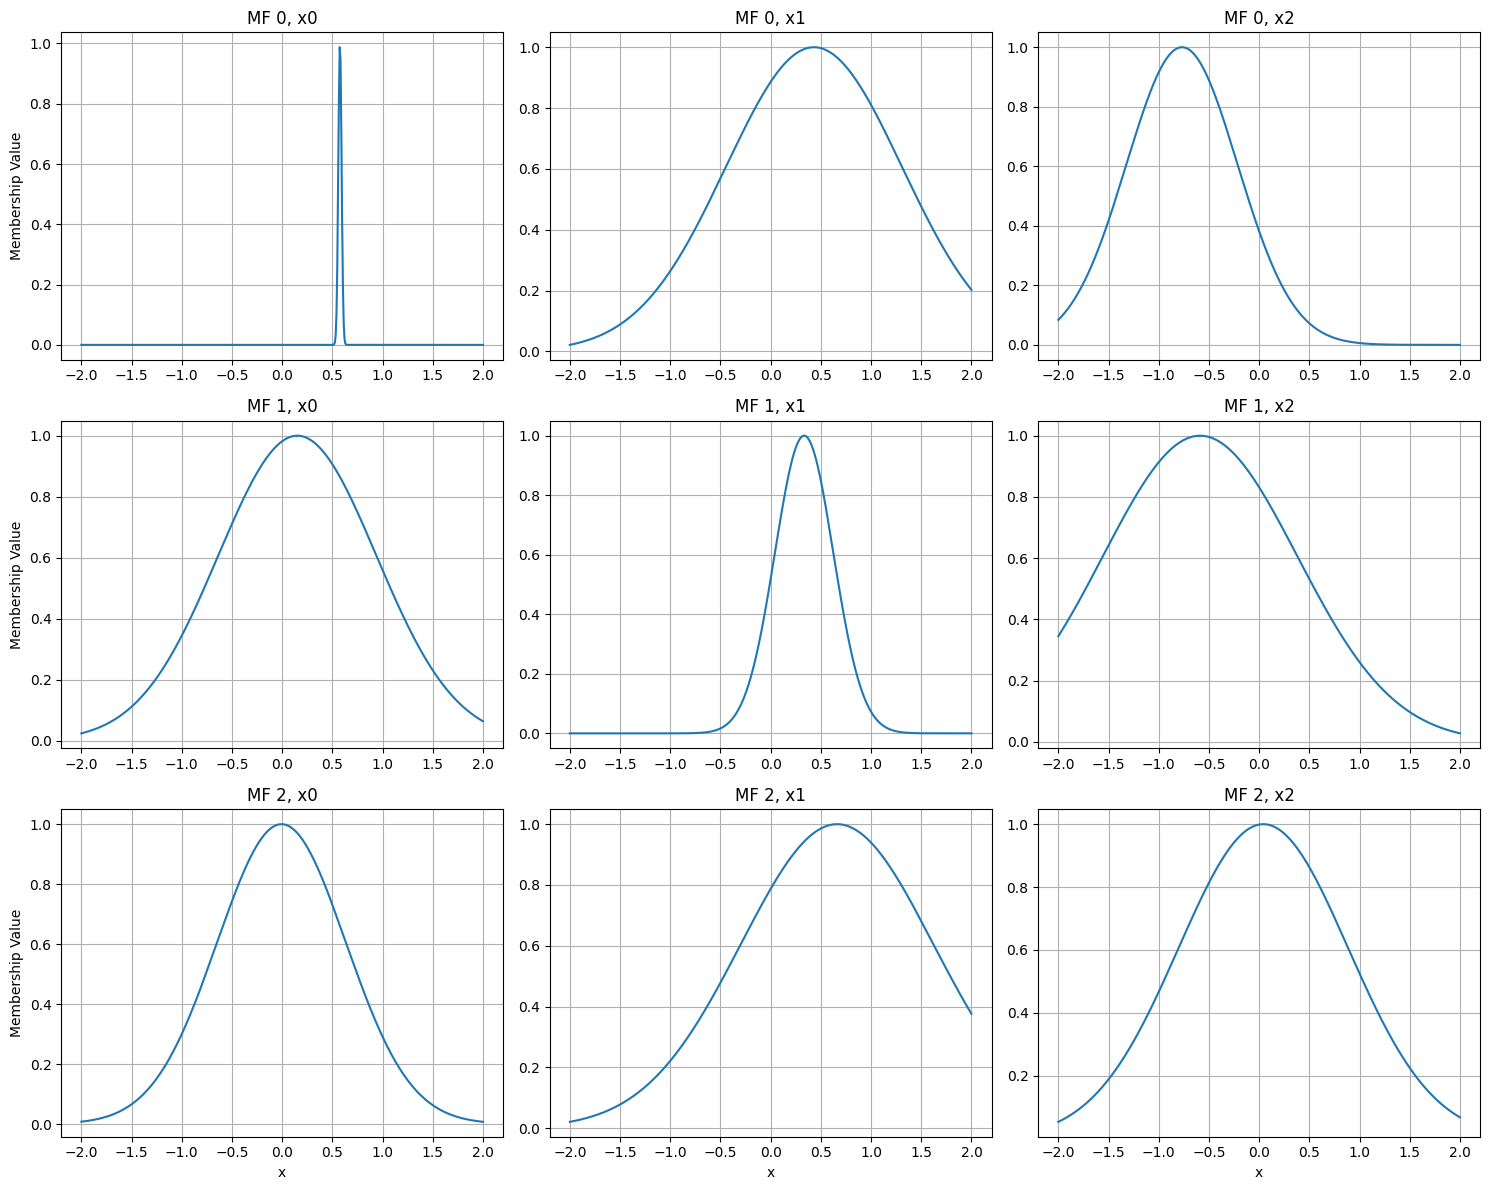

In [6]:
model.plot_premises()

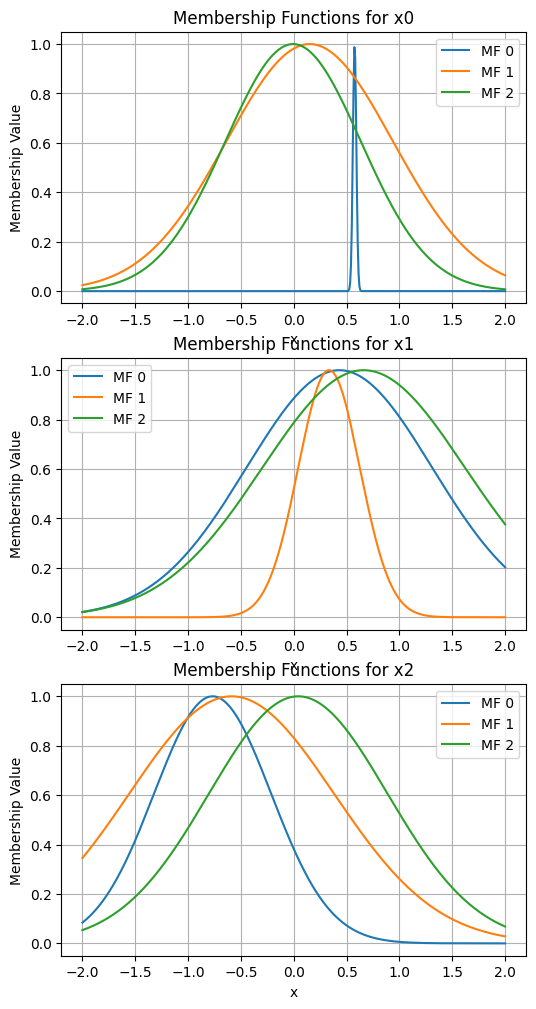

In [7]:
model.plot_premises(group_by_dim=True)

In [8]:
model.init_premises(x_train)

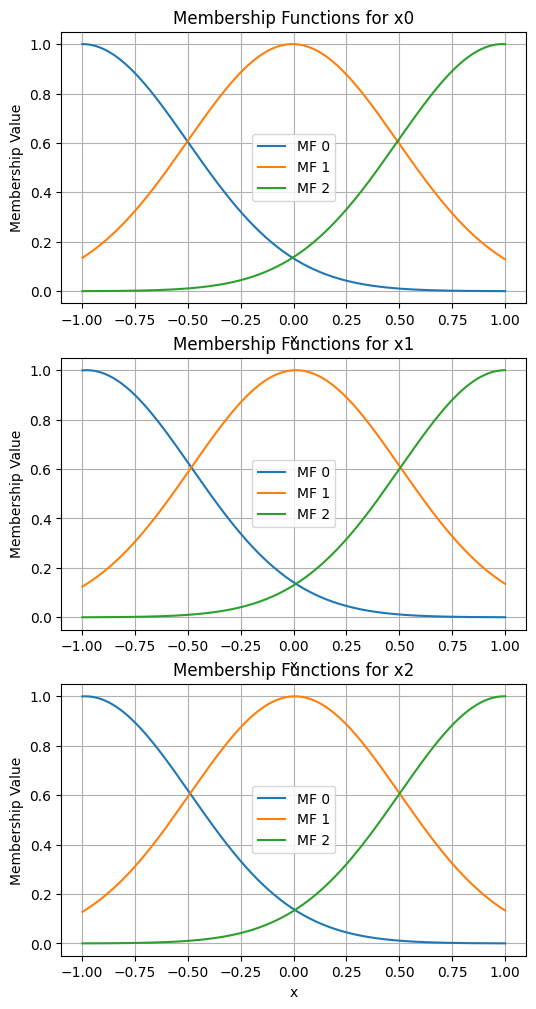

In [9]:
model.plot_premises(group_by_dim=True)

In [10]:
model.show_premises_structure()

       mu (x0)  sigma (x0)   mu (x1)  sigma (x1)   mu (x2)  sigma (x2)
MF 0 -0.997735     0.49641 -0.977175    0.494215 -0.983558    0.494909
MF 1 -0.004915     0.49641  0.011254    0.494215  0.006261    0.494909
MF 2  0.987905     0.49641  0.999683    0.494215  0.996079    0.494909


In [11]:
model.premises_structure

,mu (x0),sigma (x0),mu (x1),sigma (x1),mu (x2),sigma (x2)
MF 0,-0.997735,0.49641,-0.977175,0.494215,-0.983558,0.494909
MF 1,-0.004915,0.49641,0.011254,0.494215,0.006261,0.494909
MF 2,0.987905,0.49641,0.999683,0.494215,0.996079,0.494909


In [12]:
model.get_premises()

tensor([[[-0.9977,  0.4964],
         [-0.0049,  0.4964],
         [ 0.9879,  0.4964]],

        [[-0.9772,  0.4942],
         [ 0.0113,  0.4942],
         [ 0.9997,  0.4942]],

        [[-0.9836,  0.4949],
         [ 0.0063,  0.4949],
         [ 0.9961,  0.4949]]])

In [13]:
model.show_consequents_structure()

- Output 1:
          c0 (x0)   c1 (x1)   c2 (x2)        c3
rule 1  -0.923019 -0.892733  0.383565 -0.993349
rule 2  -0.404651 -0.620165  0.232725  0.429909
rule 3   0.678469 -0.821036 -0.527491  0.196434
rule 4  -0.905107 -0.513572 -0.746526  0.881441
rule 5  -0.827736  0.693922  0.890502 -0.097737
rule 6  -0.283041 -0.504006  0.188087  0.159300
rule 7   0.065850  0.918928 -0.519071  0.078882
rule 8   0.656303  0.146967  0.483010 -0.819631
rule 9  -0.039454 -0.086092  0.754446  0.592738
rule 10  0.403668 -0.744243 -0.580973 -0.225418
rule 11 -0.219728 -0.872083  0.745017  0.109301
rule 12 -0.989020  0.501947  0.396806 -0.159125
rule 13  0.329219 -0.989402  0.230530 -0.895829
rule 14  0.522660  0.917132 -0.752095 -0.980610
rule 15  0.844441 -0.134416  0.357299  0.796228
rule 16 -0.956957  0.839047 -0.998921 -0.425664
rule 17 -0.005818 -0.755738 -0.647921  0.413447
rule 18  0.121392  0.215006 -0.123750  0.476860
rule 19 -0.493674  0.375976  0.644679  0.930311
rule 20 -0.076442 -0.361374 

In [14]:
model.init_consequents(x_train, y_train)

In [15]:
model.show_consequents_structure()

- Output 1:
           c0 (x0)    c1 (x1)    c2 (x2)          c3
rule 1    7.000129  13.383399  17.372734   43.380131
rule 2   31.082087   2.412683  23.720873   29.086866
rule 3  -43.379330 -29.139452  11.240944  -93.067169
rule 4    2.732506  13.492290 -19.835447  -19.096220
rule 5  -10.695395   1.622230 -15.376610   -6.560552
rule 6   19.103558 -48.969036   4.050498   17.821131
rule 7   -3.655648  -2.844416  17.768387   12.509626
rule 8   15.167295  10.921630  14.995114    7.472287
rule 9  -11.278248 -81.083534  -0.797695   54.553131
rule 10  13.757941  -0.028326  -4.662701   -4.417294
rule 11  19.685022  -1.539860  -3.949841   -0.128951
rule 12 -36.924095   2.111200  11.103864    1.570264
rule 13  -2.159827 -11.598196  -1.491304   -4.478231
rule 14  -8.725370   2.967492  -5.589738   -0.215225
rule 15  19.781437  10.698096 -20.162067   18.194792
rule 16  -3.508015  -7.519908  -0.053397   11.158735
rule 17  20.107250   3.482909  -1.373014   -2.956538
rule 18 -26.111547  23.523272   3.

In [16]:
model(x_train[:10])

tensor([0.4408, 0.4173, 0.4982, 0.4199, 0.4618, 0.2335, 0.4366, 0.7330, 0.6672,
        0.6804], grad_fn=<SqueezeBackward1>)

In [17]:
with torch.no_grad():
    output = model(x_train[:10])

print(output)

tensor([0.4408, 0.4173, 0.4982, 0.4199, 0.4618, 0.2335, 0.4366, 0.7330, 0.6672,
        0.6804])


In [18]:
model.predict(x_train[:10])

array([0.4407738 , 0.41728258, 0.49815553, 0.41986692, 0.46176678,
       0.23345232, 0.4365804 , 0.7330444 , 0.667236  , 0.68035287],
      dtype=float32)

## Binary output

In [19]:
x_train = 2 * torch.rand(200, 3) - 1

In [20]:
y_train = torch.randint(0, 2, (200,))
y_train[:10]

tensor([0, 1, 1, 0, 0, 0, 1, 1, 1, 0])

In [21]:
bin_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='binary', # Tipo de salida: clasificación binaria
)

In [22]:
bin_model.predict(x_train[:10])

array([0, 0, 1, 1, 1, 0, 0, 0, 1, 0])

In [23]:
bin_model(x_train[:10])

tensor([0.4813, 0.4368, 0.5539, 0.5411, 0.7007, 0.4689, 0.4760, 0.4444, 0.6140,
        0.3538], grad_fn=<SigmoidBackward0>)

## Multiclass output

In [24]:
x_train = 2 * torch.rand(200, 3) - 1

In [25]:
y_train = torch.randint(0, 4, (200,))
y_train[:10]

tensor([2, 2, 1, 0, 0, 2, 2, 2, 3, 2])

In [26]:
mul_class_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 3 funciones de membresía
    outputs=4, # 4 clases
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='multiclass', # Tipo de salida: clasificación multiclase
)

In [27]:
mul_class_model.predict(x_train[:10])

array([1, 3, 2, 3, 3, 0, 2, 3, 3, 2])

In [28]:
mul_class_model(x_train[:10])

tensor([[ 2.2541e-01,  4.3133e-01,  3.4553e-02,  2.3228e-02],
        [ 7.9614e-02, -3.9973e-01, -6.0276e-01,  7.0147e-01],
        [-5.6930e-01, -1.5883e-01, -3.3379e-02, -6.6784e-01],
        [ 1.4066e-01,  2.7661e-01, -3.8779e-01,  7.4824e-01],
        [-4.3487e-01, -6.3539e-01, -2.7358e-01, -5.8122e-02],
        [ 4.6483e-01, -2.8780e-04, -4.0998e-01,  3.9072e-01],
        [ 1.1747e-01, -1.4455e-02,  2.3506e-01, -2.7035e-03],
        [ 5.4285e-02, -4.4047e-01, -5.8994e-01,  4.1665e-01],
        [-2.0454e-01,  1.6165e-01, -3.4160e-01,  1.0204e+00],
        [-6.5837e-02,  7.5549e-02,  1.4255e-01, -6.2294e-01]],
       grad_fn=<SqueezeBackward1>)

In [29]:
mul_class_model(x_train[:10], return_probabilities=True)

tensor([[0.2583, 0.3173, 0.2134, 0.2110],
        [0.2508, 0.1553, 0.1268, 0.4671],
        [0.1952, 0.2943, 0.3336, 0.1769],
        [0.2188, 0.2506, 0.1290, 0.4016],
        [0.2247, 0.1839, 0.2640, 0.3275],
        [0.3363, 0.2112, 0.1402, 0.3123],
        [0.2572, 0.2254, 0.2893, 0.2281],
        [0.2800, 0.1707, 0.1470, 0.4023],
        [0.1489, 0.2147, 0.1298, 0.5067],
        [0.2528, 0.2911, 0.3113, 0.1448]], grad_fn=<SoftmaxBackward0>)

## Multiple outputs

In [30]:
x_train = 2 * torch.rand(200, 2) - 1

In [31]:
model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=2, # 2 salidas
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='regression', # Tipo de salida: regresión
)

In [32]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1  0.260472 -0.691782 -0.981580
rule 2 -0.938890 -0.338946  0.365548
rule 3  0.721825 -0.833813  0.951425
rule 4 -0.377691 -0.343660  0.977585
rule 5 -0.407846 -0.922951 -0.206630
rule 6  0.713268  0.018768  0.258518
rule 7  0.174840  0.545987  0.367850
rule 8 -0.460783  0.920099 -0.919815
rule 9 -0.531980 -0.693197  0.273129


- Output 2:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.490263  0.399176  0.167766
rule 2  0.987072  0.535405 -0.217007
rule 3 -0.349460 -0.061728 -0.833155
rule 4  0.900303  0.193115  0.168224
rule 5 -0.521052  0.640395  0.111438
rule 6 -0.870106 -0.298003  0.015001
rule 7  0.664139 -0.772946 -0.450040
rule 8 -0.769759  0.494766 -0.264767
rule 9  0.427729  0.294775 -0.254787




In [33]:
model(x_train[:10])

tensor([[-0.3884,  0.1367],
        [ 0.0370, -0.4950],
        [ 0.1814, -0.1017],
        [-0.0055, -0.0902],
        [-0.2176,  0.1410],
        [ 0.3400,  0.1215],
        [ 0.0017, -0.2416],
        [-0.0757, -0.4340],
        [ 0.3653,  0.0414],
        [ 0.2496, -0.0453]], grad_fn=<SqueezeBackward1>)

## Multiclass problem

In [34]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=2, # 2 funciones de membresía
    outputs=3, # 3 salidas
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='multiclass', # Tipo de salida: clasificación multiclase
)

In [35]:
model(x_train[:10])

tensor([[-0.1701,  0.2401,  0.6706],
        [-0.1772,  0.1877, -0.6529],
        [-0.1998,  0.3301,  0.7788],
        [-0.1832,  0.2377,  0.6164],
        [ 0.2674,  0.8717,  0.6005],
        [-0.4868,  0.0647, -0.9277],
        [-0.1872, -0.0456,  0.3805],
        [ 0.0469,  0.1912, -0.4053],
        [-0.3489,  0.0489, -0.8635],
        [ 0.3467,  0.0042, -0.3082]], grad_fn=<SqueezeBackward1>)

In [36]:
model(x_train[:10], return_probabilities=True)

tensor([[0.2072, 0.3124, 0.4804],
        [0.3266, 0.4704, 0.2030],
        [0.1866, 0.3170, 0.4965],
        [0.2106, 0.3208, 0.4685],
        [0.2367, 0.4331, 0.3302],
        [0.2959, 0.5137, 0.1904],
        [0.2553, 0.2942, 0.4505],
        [0.3582, 0.4139, 0.2279],
        [0.3240, 0.4823, 0.1937],
        [0.4485, 0.3185, 0.2330]], grad_fn=<SoftmaxBackward0>)

In [37]:
model.predict(x_train[:10])

array([2, 1, 2, 2, 1, 1, 2, 1, 1, 0])

# Rule Reduced

In [38]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

In [39]:
rr_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=1, # 1 salida
    rule_reduced=True, # Reglas reducidas
)

In [40]:
rr_model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1  0.012875 -0.738636 -0.526079
rule 2  0.274582 -0.225943 -0.099596
rule 3  0.705636 -0.600408 -0.522065


